![Logo](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/shared_assets/logo.png)

**Developers:** Zoltan Barta  
**Date:** 2026-03-23  
**Version:** 2025-26/2

[<img src="https://colab.research.google.com/assets/colab-badge.svg">](https://colab.research.google.com/github/BartaZoltan/deep-reinforcement-learning-course/blob/main/notebooks/sessions/6_function_approximation/function_approximation.ipynb)

# Practice 6: Function Approximation

In Practice 5, we stayed within tabular Temporal-Difference control and studied how reward information propagates backward over multiple steps. In this session, we change a different ingredient: the representation itself. Instead of storing separate values for each state-action pair, we move to **shared parameter vectors** and learn approximate action values.

Outline:
- tile coding as a sparse feature representation,
- linear action-value approximation,
- semi-gradient SARSA and semi-gradient Q-learning on `MountainCar-v0`,
- representation and hyperparameter comparisons under both update rules,
- portability checks on `CartPole-v1` and additional environments at the end.

The main goal is to make the first step beyond tabular RL concrete before later sessions replace the linear approximator with neural networks.


## From Tabular TD Control to Function Approximation

So far the course has relied on **tabular** value functions, where each state or state-action pair owns its own separate parameter. That works well in small gridworlds, but it becomes awkward once the state space is continuous or simply too large to revisit exhaustively.

In a **tabular** RL method, we store one separate value for every state-action pair:

$$
Q(s,a)
$$

A small example for a **6-state** gridworld:

| State | Left | Right | Up | Down | Greedy action |
|---|---:|---:|---:|---:|---|
| `s0` | 0.10 | 0.35 | 0.05 | 0.20 | Right |
| `s1` | 0.25 | 0.80 | 0.10 | 0.15 | Right |
| `s2` | -0.40 | 0.05 | 0.00 | 0.60 | Down |
| `s3` | 0.30 | 0.20 | 0.55 | 0.10 | Up |
| `s4` | -0.10 | 0.40 | 0.15 | 0.70 | Down |
| `s5` | 0.00 | 0.00 | 0.00 | 0.00 | terminal |

This can be stored in a very direct way, for example as a **dictionary** or a **numpy array**. Values (state-action pairs) are cleanly seperated, to read or write them, just ask for the right index. 

`MountainCar-v0` is a simple control problem, but its state space is very different from the gridworld environments used earlier. The agent does not move between a small number of discrete cells. Instead, each state is described by two continuous variables:

$$
s = (\text{position}, \text{velocity})
$$

So a state is a point in a continuous 2D space. Two states can be extremely similar, for example they may differ only by a tiny change in position or velocity, but they are still technically different states.

This is the key reason why a tabular representation becomes impractical here. In a Q-table, we would need a separate entry for every state-action pair. But in MountainCar there is no finite list of all possible states to enumerate, because the environment contains infinitely many real-valued state points.

At the same time, many of these states are clearly related: nearby positions and velocities should usually have similar values. A plain table cannot naturally exploit this similarity, because it treats every state as completely separate. That is why we need function approximation: instead of storing one value per exact state, we learn a shared representation that can generalize across similar states.


Instead of trying to store a separate value for every exact state-action pair, we learn a parameterized function

$$
\hat{q}(s,a,\mathbf{w})
$$

that maps states and actions to estimated values. Here, $\mathbf{w}$ is a vector of learnable parameters, and the same parameters are reused across many different states.

That changes the learning problem in an important way. In a tabular method, an update only changes one exact table entry. If the agent visits a slightly different state later, that new state has to be learned almost from scratch. In a continuous environment like MountainCar, this is a poor match for the structure of the problem, because many states are very similar and should influence one another.

Function approximation allows exactly this kind of sharing. If two states are nearby in position and velocity, their value estimates can depend on overlapping features and therefore on some of the same parameters. As a result, learning at one state can improve the estimate at many related states as well.



This brings us some important changes as well:
- updates are shared through features instead of isolated table entries,
- nearby states can influence one another through overlapping representations,
- the choice of representation becomes part of the reinforcement learning problem.

## Setup

In [1]:
from __future__ import annotations

from pathlib import Path
import importlib.util
import urllib.request

import numpy as np
from IPython.display import display

try:
    import gymnasium as gym
except Exception:
    gym = None


def _load_session6_utils():
    candidates = [
        Path('utils.py'),
        Path('notebooks/sessions/6_function_approximation/utils.py'),
        Path('/content/notebooks/sessions/6_function_approximation/utils.py'),
    ]

    utils_path = next((p for p in candidates if p.exists()), None)

    if utils_path is None:
        utils_path = Path('notebooks/sessions/6_function_approximation/utils.py')
        utils_path.parent.mkdir(parents=True, exist_ok=True)
        url = (
            'https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/'
            'notebooks/sessions/6_function_approximation/utils.py'
        )
        urllib.request.urlretrieve(url, utils_path)

    spec = importlib.util.spec_from_file_location('session6_utils', utils_path)
    module = importlib.util.module_from_spec(spec)
    assert spec.loader is not None
    spec.loader.exec_module(module)
    return module


s6u = _load_session6_utils()
ASSET_ROOT = s6u.resolve_asset_root('notebooks/sessions/6_function_approximation')
SEED = 42
ACTION_NAMES = s6u.ACTION_NAMES
s6u.set_seed(SEED)

if gym is None:
    raise RuntimeError('Gymnasium is required for this notebook block. Please install gymnasium.')


### Environment: MountainCar-v0

`MountainCar-v0` is a classic control problem with a **continuous state space** and a **discrete action space**.

The state is

$$
s = (\text{position}, \text{velocity}),
$$

so each state tells us where the car is and how fast it is moving. The observation space is continuous, which means the agent can encounter many very similar but not exactly identical states.

The action space is discrete with three actions:
- push left,
- no push,
- push right.

The goal is to drive the car up the right hill and reach the target position. Because the engine is weak, the agent usually cannot solve the task by pushing directly toward the goal. It has to move back and forth to build momentum.

The reward structure is simple:
- the agent receives `-1` at every step until the goal is reached.

This means shorter successful episodes are better. The task is therefore a good example of long-term credit assignment in a continuous state space.


<div style="display:flex; justify-content:center; margin:12px 0;">
  <img src="https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/cell_outputs/semi_gradient_sarsa.gif" width="460" />
</div>



In [2]:
env = gym.make('MountainCar-v0')

print('Observation bounds:')
print('  low =', env.observation_space.low)
print('  high =', env.observation_space.high)
print('Number of actions =', env.action_space.n)
print('Actions =', ACTION_NAMES)


Observation bounds:
  low = [-1.2  -0.07]
  high = [0.6  0.07]
Number of actions = 3
Actions = {0: 'Push left', 1: 'No push', 2: 'Push right'}


The printed observation bounds describe the rectangular region in which MountainCar states live.

The state has two components:

$$
s = (\text{position}, \text{velocity})
$$

so the arrays

- `low = [position_min, velocity_min]`
- `high = [position_max, velocity_max]`

tell us the minimum and maximum possible value of each coordinate.

For MountainCar, this means:
- the first coordinate is the car's horizontal position on the track,
- the second coordinate is its current velocity,
- every valid state must lie inside this position-velocity box.


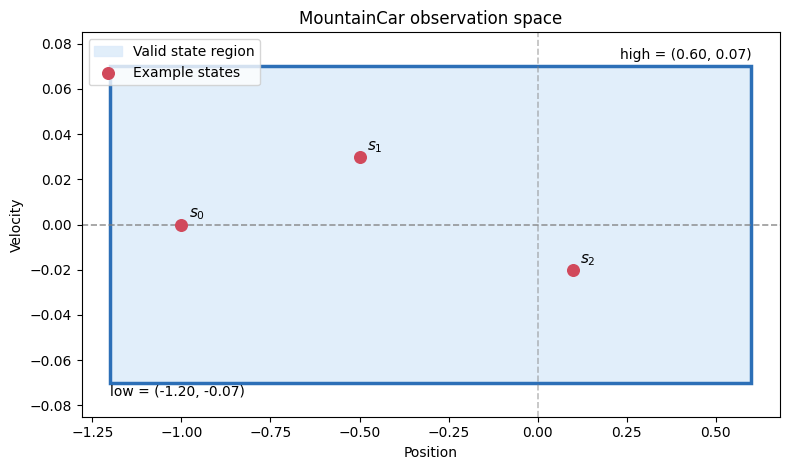

In [3]:
s6u.plot_mountaincar_observation_space(
    env,
    example_states=np.array([
        [-1.0, 0.00],
        [-0.5, 0.03],
        [0.1, -0.02],
    ])
)
 

<!-- Embedded output asset(s) -->
![cell-output](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/web_outputs/function_approximation_cell013_out00.png)


## Linear Action-Value Approximation

With linear function approximation, the action-value estimate has the form

$$
\hat{q}(s, a, \mathbf{w}) = \mathbf{w}^\top \mathbf{x}(s, a).
$$

Here $\mathbf{x}(s, a)$ is a feature vector and $\mathbf{w}$ is the weight vector we learn. In the tabular case this feature vector would just be one-hot, so linear approximation would collapse back to a table. The interesting case is when many nearby states share some of the same active features.

In this session, the feature representation comes from **tile coding**. Several slightly shifted grids cover the same state space, and each tiling activates one tile. That gives a sparse, local, and still easy-to-visualize representation.


Tile coding can be understood as a structured way to discretize a continuous state space. Instead of using only one grid, we place several slightly shifted grids, called tilings, over the same state space. For a given continuous state, each tiling activates exactly one tile, so if we use 8 tilings, then the state is first represented by 8 active tile indices. These are the plain state-based indices: they tell us which local regions of the state space are active for that state.

To turn this into an action-value representation, we then add the action information. The idea is that each action gets its own separate feature block. So after computing the 8 state-based indices, we shift them into the block corresponding to the chosen action. This means that the same state will activate different final feature indices depending on whether we evaluate `left`, `no push`, or `right`. As a result, each state-action pair is represented by 8 unique active features.

A small toy example makes this easier to see. Suppose the clean state representation produced by 4 tilings is `[3, 11, 18, 26]`. These are just the active state-based tile indices. Now suppose one action block has size `32`. The shift is then computed as

$$
\text{shift} = a \cdot \text{features\_per\_action}
$$

where `a` is the action index and here `features_per_action = 32`.

We add this shift to every clean state index. Therefore the final active feature indices become:

- for action `0`: `[3, 11, 18, 26]`
- for action `1`: `[3+32, 11+32, 18+32, 26+32] = [35, 43, 50, 58]`
- for action `2`: `[3+64, 11+64, 18+64, 26+64] = [67, 75, 82, 90]`

So the underlying state is the same, but the final active features are shifted into different action-specific blocks.

The learned approximation does not store one exact Q-value for each state-action pair like a table would. Instead, it stores a weight for every possible feature in one large weight vector. The active feature indices select the corresponding weights from that vector, and the approximate action value is obtained by summing them.



In [4]:
class TileCoder:
    """Simple dense tile coder for MountainCar state-action pairs."""

    def __init__(
        self,
        low: np.ndarray,
        high: np.ndarray,
        num_tilings: int,
        tiles: tuple[int, int],
        num_actions: int,
    ):
        self.low = np.asarray(low, dtype=float)
        self.high = np.asarray(high, dtype=float)
        self.num_tilings = int(num_tilings)
        self.tiles = np.asarray(tiles, dtype=int)
        self.num_actions = int(num_actions)

        self.state_range = self.high - self.low
        self.tiles_per_tiling = int(np.prod(self.tiles))
        self.features_per_action = self.num_tilings * self.tiles_per_tiling
        self.n_features = self.num_actions * self.features_per_action

    
        self.offsets = np.stack(
            [
                np.linspace(0.0, 1.0, self.num_tilings, endpoint=False) * (1.0 / self.tiles[d])
                for d in range(len(self.tiles))
            ],
            axis=1,
        )
    

    def tile_coordinates(self, state: np.ndarray) -> np.ndarray:
    
        state = np.asarray(state, dtype=float)
        normalized = (state - self.low) / self.state_range
        normalized = np.clip(normalized, 0.0, 1.0 - 1e-12)

        coords = np.zeros((self.num_tilings, len(self.tiles)), dtype=int)
        for tiling in range(self.num_tilings):
            shifted = normalized + self.offsets[tiling]
            coords[tiling] = np.floor(shifted * self.tiles).astype(int)
            coords[tiling] = np.clip(coords[tiling], 0, self.tiles - 1)
        return coords
    

    def encode(self, state: np.ndarray, action: int) -> np.ndarray:
    
        coords = self.tile_coordinates(state)
        active = np.empty(self.num_tilings, dtype=int)

        for tiling in range(self.num_tilings):
            flat_index = np.ravel_multi_index(tuple(coords[tiling]), self.tiles)
            active[tiling] = (
                int(action) * self.features_per_action
                + tiling * self.tiles_per_tiling
                + flat_index
            )
        return active


In [5]:
tile_coder = TileCoder(
    low=env.observation_space.low,
    high=env.observation_space.high,
    num_tilings=8,
    tiles=(8, 8),
    num_actions=env.action_space.n,
)

state = np.array([-0.50, 0.02], dtype=float)


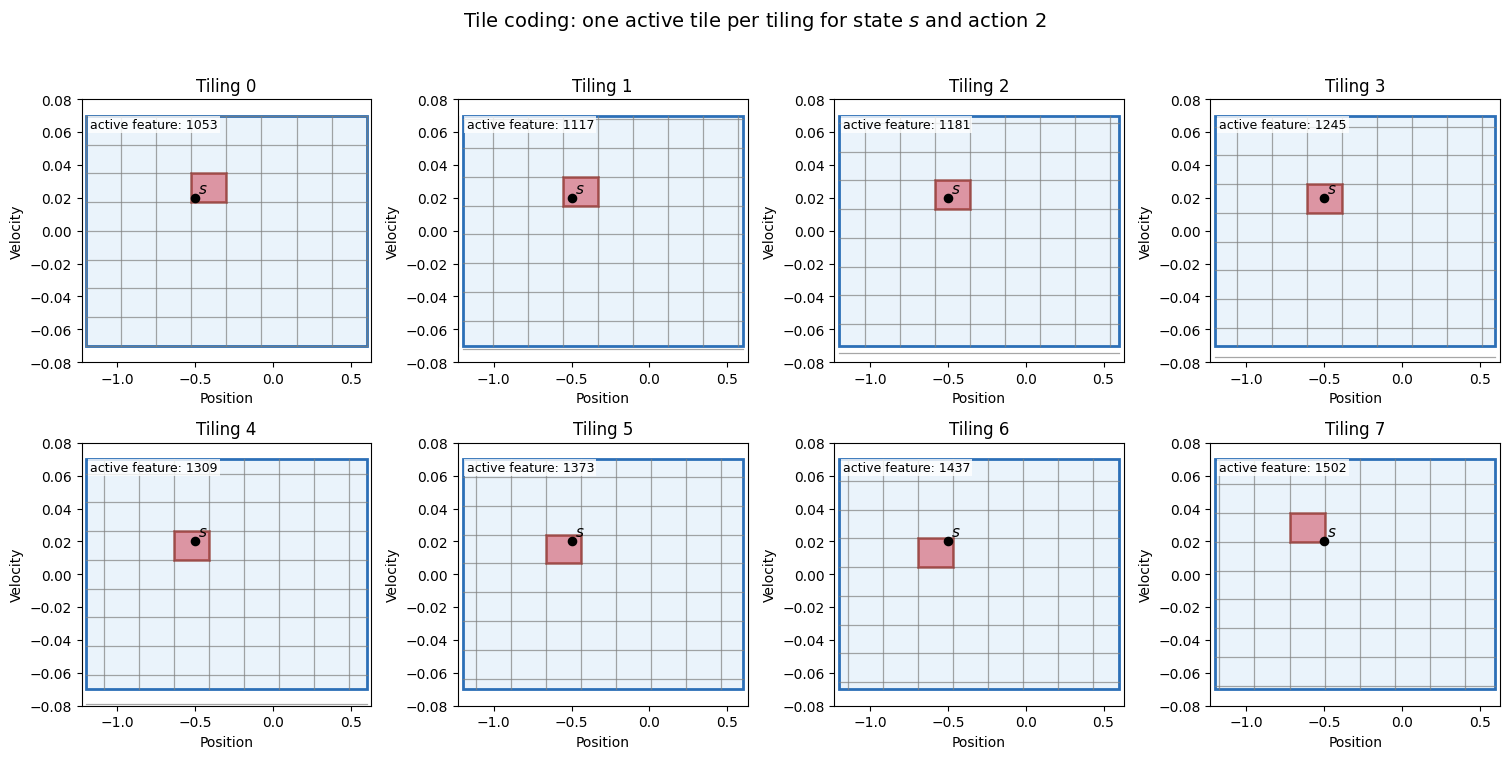

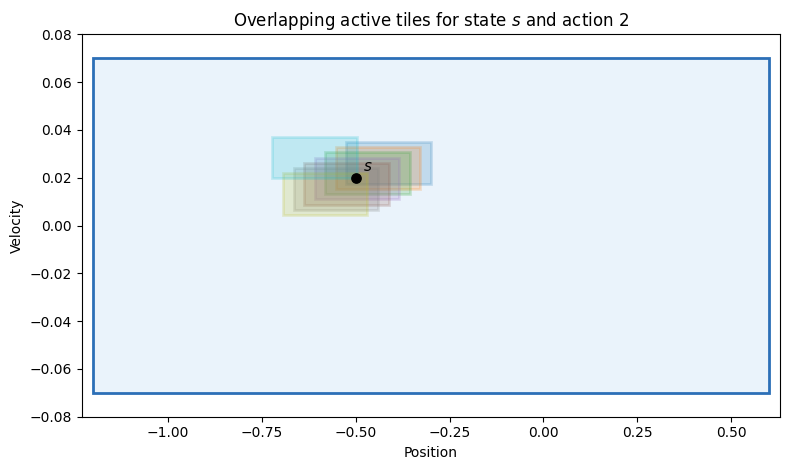

In [6]:
s6u.plot_tile_coder_activation_detailed(tile_coder, state, action=2)


<!-- Embedded output asset(s) -->
![cell-output](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/web_outputs/function_approximation_cell018_out00.png)
![cell-output](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/web_outputs/function_approximation_cell018_out01.png)


These plots show how tile coding represents one continuous MountainCar state for a fixed action. In each small panel, the same state $s$ is placed into a different shifted tiling, so exactly one tile becomes active in that tiling. The highlighted rectangle marks that active tile, and the label `active feature: ...` shows the corresponding feature index in the weight vector. This means that the state-action pair is not represented by one single table entry, but by several active features, one from each tiling. The second plot overlays these active tiles in the original state space, which makes the main idea visible: nearby states will often activate many of the same tiles, so they will share part of their representation. That is why tile coding supports generalization: learning at one state can also influence similar nearby states, because the approximate value is computed from shared active features rather than from one isolated tabular entry.

This is useful because the environment is continuous and contains many very similar states. If two states are close in position and velocity, they should usually have similar values, and tile coding makes that possible: nearby states often share many active tiles, so they also share part of their representation. Later this will be important when we attach learnable weights to these active features. Instead of storing one exact value for every state-action pair, we will combine the weights of the active tiles to form an approximate action value. That is what allows learning to generalize across similar states instead of treating every continuous state as completely separate.


## Approximate Action Values

Once the tile coder is available, the linear action-value estimate becomes very simple. For binary features,

$$
\hat{q}(s, a, \mathbf{w}) = \sum_{i \in \mathcal{A}(s, a)} w_i,
$$

where $\mathcal{A}(s, a)$ is the set of active feature indices. So evaluating an action-value means summing a small set of weights rather than looking up a table entry.

This section also adds `epsilon`-greedy action selection, because the control algorithm later on will need a policy that can both explore and exploit the current approximation.


In [7]:
def q_hat(weights: np.ndarray, active_features: np.ndarray) -> float:
    """Linear action-value estimate for one state-action pair."""
    return float(np.sum(weights[active_features]))


def q_values_for_state(weights: np.ndarray, tile_coder: TileCoder, state: np.ndarray) -> np.ndarray:
    values = np.zeros(tile_coder.num_actions, dtype=float)
    for action in range(tile_coder.num_actions):
        values[action] = q_hat(weights, tile_coder.encode(state, action))
    return values


def epsilon_greedy_action(
    weights: np.ndarray,
    tile_coder: TileCoder,
    state: np.ndarray,
    epsilon: float,
    rng: np.random.Generator,
) -> int:
    if float(rng.random()) < epsilon:
        return int(rng.integers(tile_coder.num_actions))

    q_values = q_values_for_state(weights, tile_coder, state)
    greedy_actions = np.flatnonzero(q_values == np.max(q_values))
    return int(rng.choice(greedy_actions))


In [8]:
weights_demo = np.zeros(tile_coder.n_features, dtype=float)
state_demo = np.array([-0.55, 0.01], dtype=float)
print('Initial action values:', q_values_for_state(weights_demo, tile_coder, state_demo))

rng = np.random.default_rng(SEED)
chosen_actions = [epsilon_greedy_action(weights_demo, tile_coder, state_demo, epsilon=0.10, rng=rng) for _ in range(12)]
print('Sample epsilon-greedy actions from the zero-initialized policy:', chosen_actions)


Initial action values: [0. 0. 0.]
Sample epsilon-greedy actions from the zero-initialized policy: [1, 1, 0, 0, 2, 2, 1, 1, 1, 2, 0, 1]


After the tile-coded representation is defined, we introduce a weight for every possible feature. These weights are stored in one large parameter vector. At the beginning of learning, they are usually initialized to zero, so initially no feature contributes anything to the estimated value.

The total number of weights is equal to the total number of possible action-specific features. This means that we first count how many tile-coded features belong to one action block, and then multiply by the number of actions. So if one action uses

$$
\text{features\_per\_action} = \text{num\_tilings} \times \text{tiles\_per\_tiling},
$$

then the full weight vector has size

$$
\text{num\_actions} \times \text{features\_per\_action}.
$$

For example, if we use 8 tilings, and each tiling is an $8 \times 8$ grid, then one tiling contains 64 tiles, so one action block contains

$$
8 \times 64 = 512
$$

possible features. Since MountainCar has 3 actions, the full weight vector then contains

$$
3 \times 512 = 1536
$$

weights.

At any given moment, a single state-action pair only activates 8 of these indices, one from each tiling. The approximate action value is then obtained by selecting the corresponding 8 weights and summing them. So the representation tells us which features are active, and the weight vector stores how much each of these features should contribute to the final estimated value.


For one given state, we first compute the clean tile-coded state representation. With 8 tilings, this means that the state is represented by 8 active tiles, one from each tiling. These are the plain state-based indices.

Then we evaluate the state separately for each possible action. For each action, we take the same underlying state representation and shift it into that action's feature block, which gives the active feature indices for that specific state-action pair. In this way, the same state produces a different set of active feature indices for action 0, action 1, and action 2.

For each of these state-action encodings, we then look up the corresponding weights in the global weight vector and sum them. So for the same state, we obtain one approximate action value for each action. In MountainCar with 3 actions, this gives three values:

$$
\hat{q}(s,0), \hat{q}(s,1), \hat{q}(s,2)
$$

Finally, we compare these values and select the action index with the largest one. So the overall process is:

- encode the state into 8 plain active state features,
- turn this into 3 different action-specific feature sets, one for each action,
- sum the corresponding weights for each action,
- compare the resulting action values,
- choose the action with the highest value.

This is how the approximate representation is translated into a greedy action choice.


## From Approximation to Control

The tabular SARSA update changes a single entry of the action-value table. With linear approximation, the same idea becomes a weight update:

$$
\delta_t = R_{t+1} + \gamma \hat{q}(S_{t+1}, A_{t+1}, \mathbf{w}) - \hat{q}(S_t, A_t, \mathbf{w}),
$$

$$
\mathbf{w} \leftarrow \mathbf{w} + \alpha \, \delta_t \, \nabla \hat{q}(S_t, A_t, \mathbf{w}).
$$

For tile-coded binary features, the gradient is just the active feature vector, so the update only changes the weights attached to the currently active tiles.

This is called a **semi-gradient** method because the target contains a bootstrapped estimate that also depends on the current weights, but the update treats that target as fixed when differentiating.


In [9]:
def semi_gradient_sarsa(
    env,
    tile_coder: TileCoder,
    n_episodes: int,
    alpha: float,
    gamma: float = 1.0,
    epsilon: float = 0.1,
    max_steps: int = 200,
    seed: int = SEED,
):
    """Semi-gradient SARSA with linear tile-coded action values."""
    rng = np.random.default_rng(seed)
    weights = np.zeros(tile_coder.n_features, dtype=float)
    episode_returns = []
    episode_lengths = []
    start_cost_history = []

    for _ in range(n_episodes):
        state, _ = env.reset(seed=int(rng.integers(0, 10_000_000)))
        state = np.asarray(state, dtype=float)
        action = epsilon_greedy_action(weights, tile_coder, state, epsilon, rng)
        total_return = 0.0

        for step in range(max_steps):
            active_features = tile_coder.encode(state, action)
            next_state, reward, terminated, truncated, _ = env.step(action)
            next_state = np.asarray(next_state, dtype=float)
            total_return += float(reward)

            if terminated or truncated:
                delta = float(reward) - q_hat(weights, active_features)
                weights[active_features] += alpha * delta
                episode_lengths.append(step + 1)
                break

            next_action = epsilon_greedy_action(weights, tile_coder, next_state, epsilon, rng)
            next_active = tile_coder.encode(next_state, next_action)
            delta = float(reward) + gamma * q_hat(weights, next_active) - q_hat(weights, active_features)
            weights[active_features] += alpha * delta

            state = next_state
            action = next_action
        else:
            episode_lengths.append(max_steps)

        episode_returns.append(total_return)
        if tile_coder.low.shape == (2,):
            reference_state = np.array([-0.5, 0.0], dtype=float)
        else:
            reference_state = np.clip(np.zeros_like(tile_coder.low), tile_coder.low, tile_coder.high)
        start_cost_history.append(-np.max(q_values_for_state(weights, tile_coder, reference_state)))

    return {
        'weights': weights,
        'returns': np.asarray(episode_returns, dtype=float),
        'lengths': np.asarray(episode_lengths, dtype=float),
        'start_cost': np.asarray(start_cost_history, dtype=float),
    }


In [10]:
def semi_gradient_q_learning(
    env,
    tile_coder: TileCoder,
    n_episodes: int,
    alpha: float,
    gamma: float = 1.0,
    epsilon: float = 0.1,
    max_steps: int = 200,
    seed: int = SEED,
):
    """Semi-gradient Q-learning with linear tile-coded action values."""
    rng = np.random.default_rng(seed)
    weights = np.zeros(tile_coder.n_features, dtype=float)
    episode_returns = []
    episode_lengths = []
    start_cost_history = []

    for _ in range(n_episodes):
        state, _ = env.reset(seed=int(rng.integers(0, 10_000_000)))
        state = np.asarray(state, dtype=float)
        total_return = 0.0

        for step in range(max_steps):
            action = epsilon_greedy_action(weights, tile_coder, state, epsilon, rng)
            active_features = tile_coder.encode(state, action)
            next_state, reward, terminated, truncated, _ = env.step(action)
            next_state = np.asarray(next_state, dtype=float)
            total_return += float(reward)

            if terminated or truncated:
                delta = float(reward) - q_hat(weights, active_features)
                weights[active_features] += alpha * delta
                episode_lengths.append(step + 1)
                break

            next_q = np.max(q_values_for_state(weights, tile_coder, next_state))
            delta = float(reward) + gamma * next_q - q_hat(weights, active_features)
            weights[active_features] += alpha * delta
            state = next_state
        else:
            episode_lengths.append(max_steps)

        episode_returns.append(total_return)
        if tile_coder.low.shape == (2,):
            reference_state = np.array([-0.5, 0.0], dtype=float)
        else:
            reference_state = np.clip(np.zeros_like(tile_coder.low), tile_coder.low, tile_coder.high)
        start_cost_history.append(-np.max(q_values_for_state(weights, tile_coder, reference_state)))

    return {
        'weights': weights,
        'returns': np.asarray(episode_returns, dtype=float),
        'lengths': np.asarray(episode_lengths, dtype=float),
        'start_cost': np.asarray(start_cost_history, dtype=float),
    }

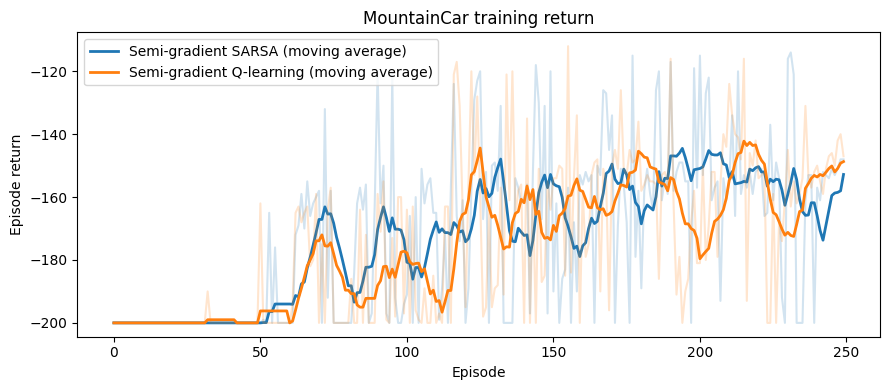

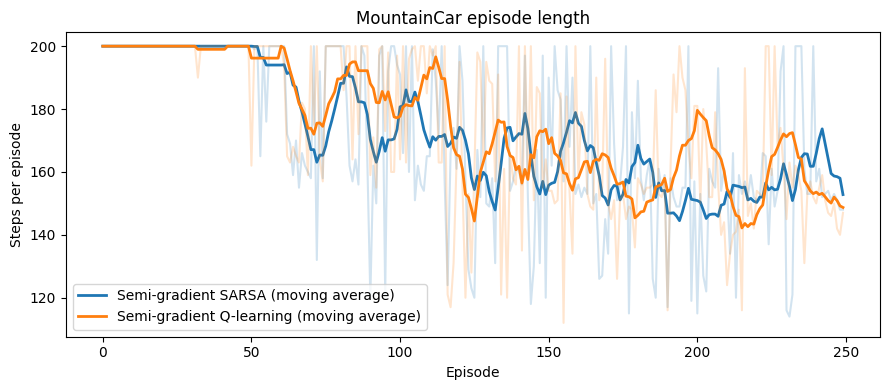

Semi-gradient SARSA representative rollout: {'seed': 49, 'return': -147.0, 'steps': 147, 'terminated': True}
Semi-gradient Q-learning representative rollout: {'seed': 53, 'return': -130.0, 'steps': 130, 'terminated': True}
Representative training comparison GIFs generated.



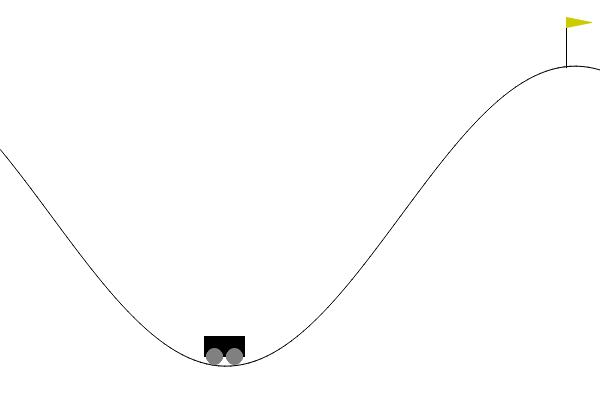
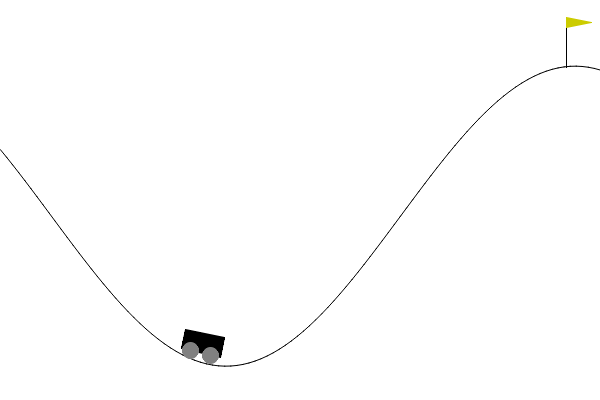

In [11]:
training_algorithms = {
    'Semi-gradient SARSA': semi_gradient_sarsa,
    'Semi-gradient Q-learning': semi_gradient_q_learning,
}

training_comparison = {}
for label, algorithm in training_algorithms.items():
    training_comparison[label] = algorithm(
        env,
        tile_coder,
        n_episodes=250,
        alpha=0.30 / tile_coder.num_tilings,
        gamma=1.0,
        epsilon=0.10,
        max_steps=200,
        seed=SEED,
    )

s6u.plot_many_curves(
    {label: run['returns'] for label, run in training_comparison.items()},
    title='MountainCar training return',
    ylabel='Episode return',
    window=10,
)

s6u.plot_many_curves(
    {label: run['lengths'] for label, run in training_comparison.items()},
    title='MountainCar episode length',
    ylabel='Steps per episode',
    window=10,
)

# s6u.plot_many_curves(
#     {label: run['start_cost'] for label, run in training_comparison.items()},
#     title='Estimated cost-to-go of the reference state',
#     ylabel='Estimated cost-to-go',
#     window=10,
# )

training_gif_items = []
for label, run in training_comparison.items():
    rollout = s6u.select_representative_greedy_rollout(
        env,
        run['weights'],
        tile_coder,
        q_values_fn=q_values_for_state,
        objective='min_steps_success',
        n_candidates=24,
        max_steps=200,
        seed=SEED,
    )
    print(label, 'representative rollout:', {
        'seed': rollout['seed'],
        'return': rollout['total_return'],
        'steps': rollout['steps'],
        'terminated': rollout['terminated'],
    })
    gif = s6u.export_greedy_rollout_gif(
        'MountainCar-v0',
        run['weights'],
        tile_coder,
        q_values_fn=q_values_for_state,
        output_dir=ASSET_ROOT,
        gif_name=f'{label.lower().replace(" ", "_").replace("-", "_")}.gif',
        max_steps=200,
        seed=SEED,
        fps=15.0,
        objective='min_steps_success',
        n_candidates=24,
    )
    training_gif_items.append({'title': label, 'gif_path': gif['gif_path']})

print('Representative training comparison GIFs generated.')
display(s6u.render_side_by_side_gifs(training_gif_items, width=420))

<!-- Embedded output asset(s) -->

<div style="display:grid; grid-template-columns: repeat(2, minmax(260px, 1fr)); gap:24px; align-items:start;">
  <div style="text-align:center;">
    <p><strong>Semi-gradient SARSA</strong></p>
    <img src="https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/cell_outputs/semi_gradient_sarsa.gif" width="380" />
  </div>
  <div style="text-align:center;">
    <p><strong>Semi-gradient Q-learning</strong></p>
    <img src="https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/cell_outputs/semi_gradient_q_learning.gif" width="380" />
  </div>
</div>



## Experiment: feature granularity


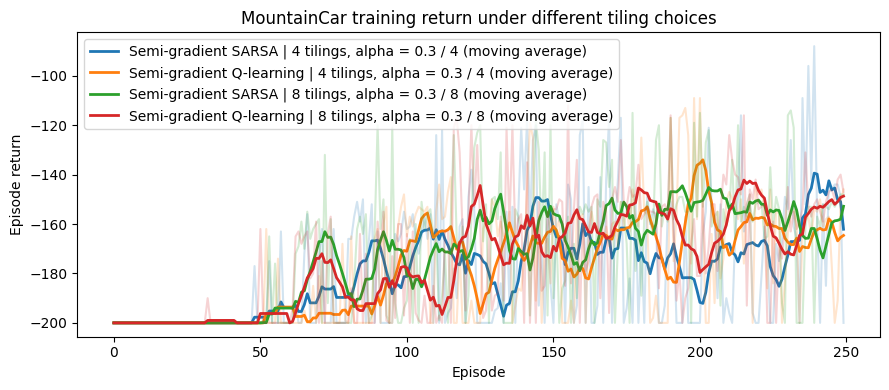

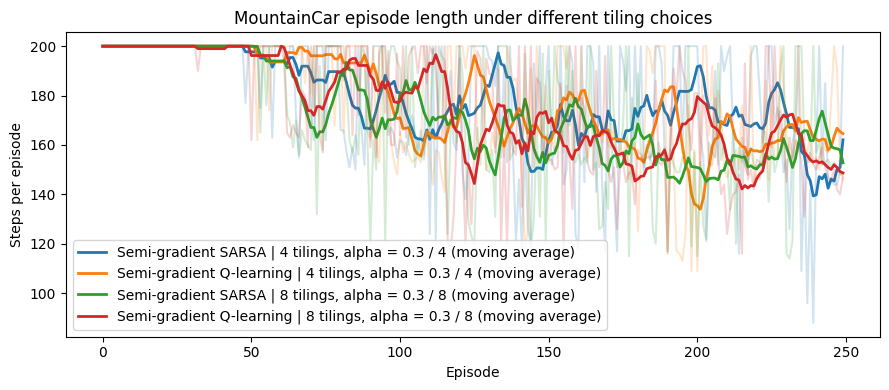

Using this run for generic visualization: Semi-gradient SARSA | 4 tilings, alpha = 0.3 / 4
Best Semi-gradient SARSA run: Semi-gradient SARSA | 4 tilings, alpha = 0.3 / 4
Best Semi-gradient Q-learning run: Semi-gradient Q-learning | 8 tilings, alpha = 0.3 / 8


In [12]:
experiment_runs = {}
configs = [
    {'label': '4 tilings, alpha = 0.3 / 4', 'num_tilings': 4, 'tiles': (8, 8), 'alpha': 0.3 / 4},
    {'label': '8 tilings, alpha = 0.3 / 8', 'num_tilings': 8, 'tiles': (8, 8), 'alpha': 0.3 / 8},
]
algorithms = {
    'Semi-gradient SARSA': semi_gradient_sarsa,
    'Semi-gradient Q-learning': semi_gradient_q_learning,
}

for cfg in configs:
    for algorithm_label, algorithm in algorithms.items():
        coder = TileCoder(
            low=env.observation_space.low,
            high=env.observation_space.high,
            num_tilings=cfg['num_tilings'],
            tiles=cfg['tiles'],
            num_actions=env.action_space.n,
        )
        run = algorithm(
            env,
            coder,
            n_episodes=250,
            alpha=cfg['alpha'],
            gamma=1.0,
            epsilon=0.1,
            max_steps=200,
            seed=SEED,
        )
        key = f'{algorithm_label} | {cfg["label"]}'
        experiment_runs[key] = {
            'algorithm': algorithm_label,
            'config_label': cfg['label'],
            'coder': coder,
            **run,
        }

s6u.plot_many_curves(
    {label: run['returns'] for label, run in experiment_runs.items()},
    title='MountainCar training return under different tiling choices',
    ylabel='Episode return',
    window=10,
)
s6u.plot_many_curves(
    {label: run['lengths'] for label, run in experiment_runs.items()},
    title='MountainCar episode length under different tiling choices',
    ylabel='Steps per episode',
    window=10,
)
# s6u.plot_many_curves(
#     {label: run['start_cost'] for label, run in experiment_runs.items()},
#     title='Estimated cost-to-go of the canonical start state',
#     ylabel='Estimated cost-to-go',
#     window=10,
# )

best_label = max(
    experiment_runs,
    key=lambda label: float(np.mean(experiment_runs[label]['returns'][-20:])),
)
best_run = experiment_runs[best_label]
best_tile_coder = best_run['coder']
best_weights = best_run['weights']

best_runs_by_algorithm = {}
for algorithm_label in algorithms:
    candidate_labels = [label for label, run in experiment_runs.items() if run['algorithm'] == algorithm_label]
    best_algorithm_label = max(
        candidate_labels,
        key=lambda label: float(np.mean(experiment_runs[label]['returns'][-20:])),
    )
    best_runs_by_algorithm[algorithm_label] = {
        'label': best_algorithm_label,
        **experiment_runs[best_algorithm_label],
    }

print('Using this run for generic visualization:', best_label)
for algorithm_label, run in best_runs_by_algorithm.items():
    print(f'Best {algorithm_label} run:', run['label'])

<!-- Embedded output asset(s) -->
![cell-output](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/web_outputs/function_approximation_cell030_out00.png)
![cell-output](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/web_outputs/function_approximation_cell030_out01.png)


These plots show the same comparison from two slightly different perspectives. The return curve tells us whether the agent is escaping the worst `-200` behavior and learning to solve the task in fewer steps. The episode-length curve shows the same improvement more directly: in MountainCar, shorter episodes usually mean that the policy has learned how to build momentum and reach the goal more efficiently. The `4 tilings` versus `8 tilings` comparison shows the effect of representation quality. With more tilings, the feature map can describe the continuous state space more precisely, so learning often becomes smoother and the resulting policy more coherent, although the extra overlap also changes how each update spreads through the weights. The `SARSA` versus `Q-learning` comparison isolates the effect of the update rule. Since the feature map is the same, any consistent difference between those curves comes from the target: SARSA updates toward the value of the next action actually taken, while Q-learning updates toward the greedy next-state estimate. That is why the two algorithms can react differently even under the same tiling scheme.


## Experiment: step-size sensitivity


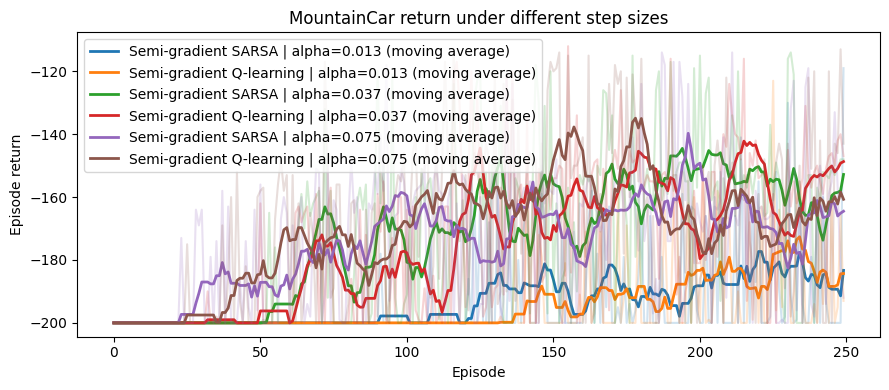

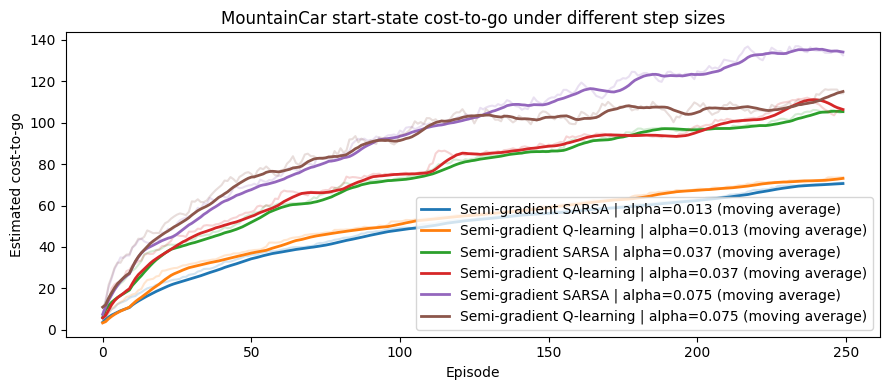

In [13]:
step_size_runs = {}
alpha_grid = [0.10 / 8, 0.30 / 8, 0.60 / 8]
algorithms = {
    'Semi-gradient SARSA': semi_gradient_sarsa,
    'Semi-gradient Q-learning': semi_gradient_q_learning,
}

for alpha in alpha_grid:
    for algorithm_label, algorithm in algorithms.items():
        coder = TileCoder(
            low=env.observation_space.low,
            high=env.observation_space.high,
            num_tilings=8,
            tiles=(8, 8),
            num_actions=env.action_space.n,
        )
        key = f'{algorithm_label} | alpha={alpha:.3f}'
        step_size_runs[key] = algorithm(
            env,
            coder,
            n_episodes=250,
            alpha=alpha,
            gamma=1.0,
            epsilon=0.1,
            max_steps=200,
            seed=SEED,
        )

s6u.plot_many_curves(
    {label: run['returns'] for label, run in step_size_runs.items()},
    title='MountainCar return under different step sizes',
    ylabel='Episode return',
    window=10,
)
s6u.plot_many_curves(
    {label: run['start_cost'] for label, run in step_size_runs.items()},
    title='MountainCar start-state cost-to-go under different step sizes',
    ylabel='Estimated cost-to-go',
    window=10,
)

<!-- Embedded output asset(s) -->
![cell-output](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/web_outputs/function_approximation_cell033_out00.png)
![cell-output](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/web_outputs/function_approximation_cell033_out01.png)


These plots isolate the effect of the step size `alpha` while keeping the representation fixed. What matters here is not only which run ends up best, but how the whole learning process behaves. With a very small step size, improvement is usually slow because each update changes the weights only a little. With a larger step size, learning can speed up, but beyond a point the curves often become noisy or unstable because each transition pushes the approximation too aggressively. A good step size usually appears as a cleaner, steadier improvement in both return and episode length. This matters especially with tile coding, because each semi-gradient update is applied not to one single value but to several active weights at once. Increasing `alpha` therefore strengthens every shared update, and that can affect SARSA and Q-learning differently, since their bootstrap targets are not the same. If the curves separate, that difference is coming from the interaction between step size, shared features, and update rule.


## Experiment: exploration rate

The step-size experiment isolates the effect of `alpha`. This experiment keeps the representation and step size fixed, and changes only `epsilon`.

That matters for both algorithms, but in slightly different ways. Semi-gradient SARSA directly bootstraps from the behavior policy, while semi-gradient Q-learning still behaves `epsilon`-greedily but bootstraps from a greedy next-state estimate. Comparing the two makes the role of exploration easier to see in approximate control.

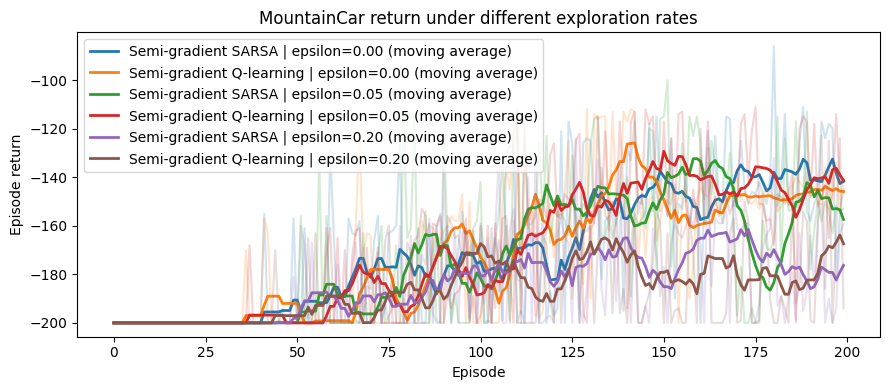

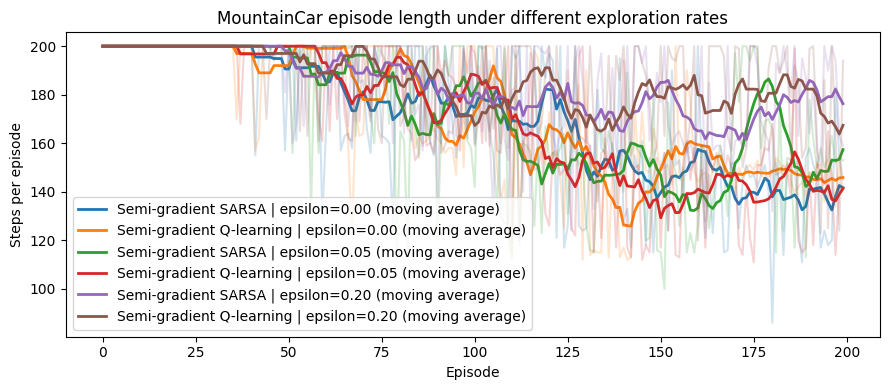

In [14]:
epsilon_runs = {}
epsilon_grid = [0.00, 0.05, 0.20]
algorithms = {
    'Semi-gradient SARSA': semi_gradient_sarsa,
    'Semi-gradient Q-learning': semi_gradient_q_learning,
}

for epsilon in epsilon_grid:
    for algorithm_label, algorithm in algorithms.items():
        coder = TileCoder(
            low=env.observation_space.low,
            high=env.observation_space.high,
            num_tilings=8,
            tiles=(8, 8),
            num_actions=env.action_space.n,
        )
        key = f'{algorithm_label} | epsilon={epsilon:.2f}'
        epsilon_runs[key] = algorithm(
            env,
            coder,
            n_episodes=200,
            alpha=0.30 / 8,
            gamma=1.0,
            epsilon=epsilon,
            max_steps=200,
            seed=SEED,
        )

s6u.plot_many_curves(
    {label: run['returns'] for label, run in epsilon_runs.items()},
    title='MountainCar return under different exploration rates',
    ylabel='Episode return',
    window=10,
)
s6u.plot_many_curves(
    {label: run['lengths'] for label, run in epsilon_runs.items()},
    title='MountainCar episode length under different exploration rates',
    ylabel='Steps per episode',
    window=10,
)

<!-- Embedded output asset(s) -->
![cell-output](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/web_outputs/function_approximation_cell036_out00.png)
![cell-output](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/web_outputs/function_approximation_cell036_out01.png)


These plots show how the exploration rate changes the learning dynamics, but they should not be read too rigidly. Even with `epsilon = 0.00`, learning can still happen, especially early on, because the policy may still contain some randomness through tie-breaking when several actions have the same value. So `epsilon = 0.00` does not necessarily mean “no learning at all”; it means that after these initial ambiguities disappear, the policy stops deliberately exploring and becomes fully driven by its current approximation. In some runs that is already enough to make progress, while in others it can lock the agent into a limited behavior too early. With a moderate exploration rate, learning is often more reliable, because the agent continues to visit new state-action regions while still exploiting what it has already learned. With a large exploration rate, the curves usually become noisier, since the behavior policy keeps injecting random actions even after a useful strategy has started to form. The SARSA versus Q-learning comparison is also informative here, because the same exploratory behavior enters the two updates differently: SARSA bootstraps from the value of the next action actually taken, while Q-learning bootstraps from the greedy next-state value. That is why the same `epsilon` can influence the two algorithms in different ways.


## Visualizing the Learned Value Function

A learned approximate action-value function becomes much easier to interpret when it is projected back onto the state space. In MountainCar, a standard diagnostic is the **cost-to-go surface**,

$$
-\max_a \hat{q}(s, a, \mathbf{w}),
$$

which estimates how many more steps the current greedy policy still expects to need from each region.

A second useful diagnostic is the greedy action map, which shows which action the approximation currently prefers at each point in the position-velocity plane.


In [15]:
def cost_to_go_grid(
    weights: np.ndarray,
    tile_coder: TileCoder,
    position_values: np.ndarray,
    velocity_values: np.ndarray,
) -> np.ndarray:
    grid = np.zeros((len(velocity_values), len(position_values)), dtype=float)
    for i, velocity in enumerate(velocity_values):
        for j, position in enumerate(position_values):
            state = np.array([position, velocity], dtype=float)
            grid[i, j] = -np.max(q_values_for_state(weights, tile_coder, state))
    return grid



def greedy_action_grid(
    weights: np.ndarray,
    tile_coder: TileCoder,
    position_values: np.ndarray,
    velocity_values: np.ndarray,
) -> np.ndarray:
    grid = np.zeros((len(velocity_values), len(position_values)), dtype=int)
    for i, velocity in enumerate(velocity_values):
        for j, position in enumerate(position_values):
            state = np.array([position, velocity], dtype=float)
            grid[i, j] = int(np.argmax(q_values_for_state(weights, tile_coder, state)))
    return grid


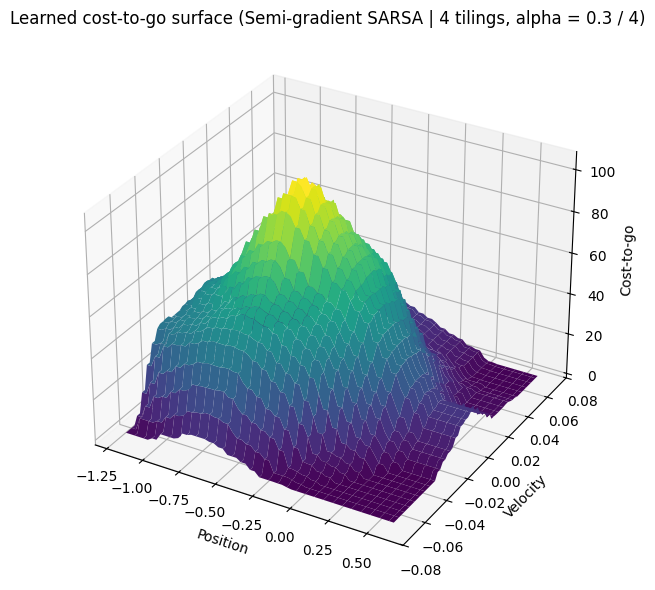

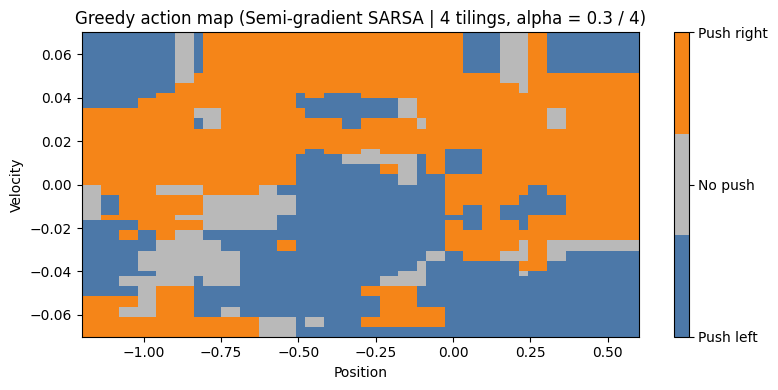

In [16]:
position_values = np.linspace(env.observation_space.low[0], env.observation_space.high[0], 60)
velocity_values = np.linspace(env.observation_space.low[1], env.observation_space.high[1], 60)

cost_grid = cost_to_go_grid(best_weights, best_tile_coder, position_values, velocity_values)
action_grid = greedy_action_grid(best_weights, best_tile_coder, position_values, velocity_values)

s6u.plot_cost_to_go_surface(
    cost_grid,
    position_values,
    velocity_values,
    title=f'Learned cost-to-go surface ({best_label})',
)
s6u.plot_greedy_action_map(
    action_grid,
    position_values,
    velocity_values,
    title=f'Greedy action map ({best_label})',
)


<!-- Embedded output asset(s) -->
![cell-output](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/web_outputs/function_approximation_cell040_out00.png)
![cell-output](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/web_outputs/function_approximation_cell040_out01.png)


These two visualizations give the most direct picture of what the approximation has learned over the MountainCar state space. The cost-to-go surface shows how difficult different states look under the current greedy policy: lower regions correspond to states from which the goal appears closer, while higher regions correspond to states from which more work is still needed. The greedy action map shows which action the approximation prefers at each point in the position-velocity plane. What matters here is not isolated pixels, but the larger structure. If learning has worked well, the action map should contain broad, coherent regions, and the pattern should reflect the main MountainCar strategy: the agent often has to move away from the goal first, build momentum, and only then drive upward successfully. This is the main payoff of the session, because it shows that even a simple linear approximator can represent a meaningful control policy in a continuous state space when the feature representation is chosen carefully.


## Example: greedy MountainCar rollout

Scalar learning curves and value-surface plots are useful, but they still do not show how the learned policy actually behaves over time. This example searches over several initial seeds and then visualizes one representative greedy episode under the best MountainCar approximation found in the earlier algorithm-and-tiling comparisons.

Using a representative rollout matters here: in MountainCar, the same greedy policy can look noticeably different across initial states, so a single fixed seed can easily give a misleading impression of the learned behavior.

Representative greedy rollout: {'seed': 47, 'return': -136.0, 'steps': 136, 'terminated': True}
Greedy policy evaluation: {'mean_return': -155.8, 'std_return': 23.871740615212794, 'mean_length': 155.8}


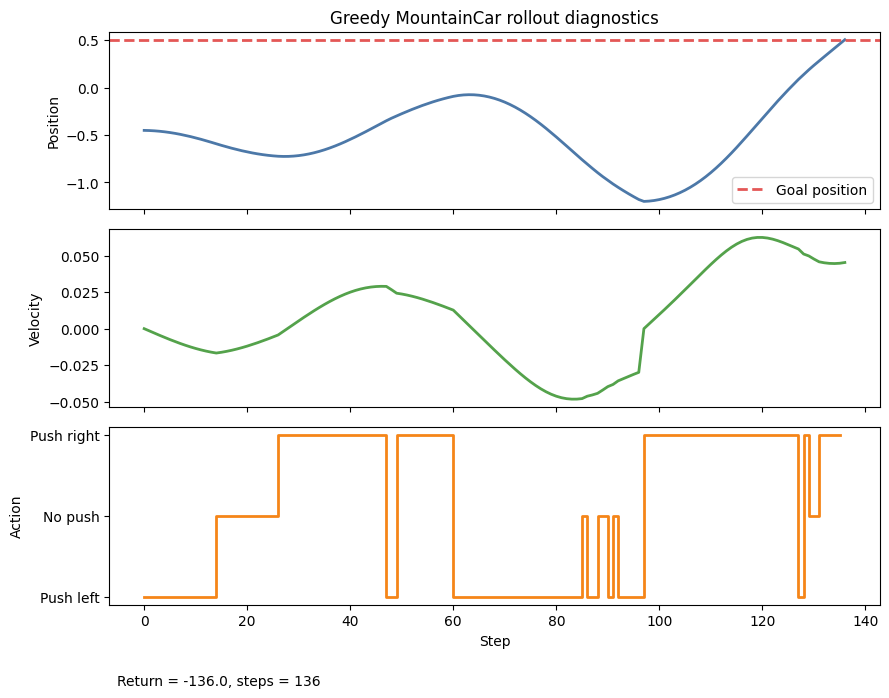

In [17]:
mountaincar_rollout = s6u.select_representative_greedy_rollout(
    env,
    best_weights,
    best_tile_coder,
    q_values_fn=q_values_for_state,
    objective='min_steps_success',
    n_candidates=32,
    max_steps=200,
    seed=SEED,
)
mountaincar_eval = s6u.evaluate_greedy_policy(
    env,
    best_weights,
    best_tile_coder,
    q_values_fn=q_values_for_state,
    n_episodes=20,
    max_steps=200,
    seed=SEED,
)

print('Representative greedy rollout:', {
    'seed': mountaincar_rollout['seed'],
    'return': mountaincar_rollout['total_return'],
    'steps': mountaincar_rollout['steps'],
    'terminated': mountaincar_rollout['terminated'],
})
print('Greedy policy evaluation:', mountaincar_eval)
s6u.plot_mountaincar_rollout(mountaincar_rollout, goal_position=env.unwrapped.goal_position)

<!-- Embedded output asset(s) -->
![cell-output](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/web_outputs/function_approximation_cell043_out01.png)


This rollout plot shows the learned MountainCar strategy in time order. The position curve should make it clear that the car does not simply drive straight toward the goal. Instead, it first moves away to build momentum, then uses that momentum to climb higher on the opposite side. The velocity curve should reflect this back-and-forth pumping behavior, and the action sequence should show longer stretches of consistent pushing rather than rapid random switching. Because this plot is taken from a representative successful rollout chosen from several seeds, it gives a more trustworthy picture of the learned policy than a single arbitrary episode. It is also a useful complement to the state-space visualizations: the cost-to-go surface and the action map show what the approximation has learned across states, while the rollout shows how that learned structure appears as an actual trajectory over time.


## GIF Visualization: MountainCar rollouts

The next block renders four greedy rollouts from the feature-granularity experiment: semi-gradient SARSA with `4` and `8` tilings, and semi-gradient Q-learning with `4` and `8` tilings. Instead of using a single fixed start, each GIF is selected from several candidate seeds so that the animation shows a normal, representative successful trajectory for the learned policy.


In [18]:
from pathlib import Path
from IPython.display import display
import ipywidgets as widgets

mountaincar_gif_labels = [
    'Semi-gradient SARSA | 4 tilings, alpha = 0.3 / 4',
    'Semi-gradient SARSA | 8 tilings, alpha = 0.3 / 8',
    'Semi-gradient Q-learning | 4 tilings, alpha = 0.3 / 4',
    'Semi-gradient Q-learning | 8 tilings, alpha = 0.3 / 8',
]

mountaincar_gif_items = []
for label in mountaincar_gif_labels:
    run = experiment_runs[label]
    short_algorithm = run['algorithm'].replace('Semi-gradient ', '')
    short_config = run['config_label'].split(',')[0]
    tilings = run['coder'].num_tilings

    algorithm_slug = (
        run['algorithm']
        .lower()
        .replace('semi-gradient ', '')
        .replace(' ', '_')
        .replace('-', '_')
    )
    slug = f'mountaincar_{algorithm_slug}_{tilings}_tilings'

    gif = s6u.export_greedy_rollout_gif(
        'MountainCar-v0',
        run['weights'],
        run['coder'],
        q_values_fn=q_values_for_state,
        output_dir=ASSET_ROOT,
        gif_name=f'{slug}.gif',
        max_steps=200,
        seed=SEED,
        fps=15.0,
        objective='min_steps_success',
        n_candidates=32,
    )

    print(f'{short_algorithm} | {short_config}:', gif)
    mountaincar_gif_items.append({
        'title': f'{short_algorithm} | {short_config}',
        'gif_path': gif['gif_path'],
    })

gif_boxes = []
for item in mountaincar_gif_items:
    gif_bytes = Path(item['gif_path']).read_bytes()
    gif_widget = widgets.Image(
        value=gif_bytes,
        format='gif',
        width=320,
    )
    title_widget = widgets.HTML(
        value=f"<b>{item['title']}</b>"
    )
    gif_boxes.append(
        widgets.VBox(
            [title_widget, gif_widget],
            layout=widgets.Layout(align_items='center', width='340px')
        )
    )

display(
    widgets.VBox([
        widgets.HBox(gif_boxes[:2], layout=widgets.Layout(justify_content='center', gap='24px')),
        widgets.HBox(gif_boxes[2:], layout=widgets.Layout(justify_content='center', gap='24px')),
    ], layout=widgets.Layout(gap='24px'))
)


SARSA | 4 tilings: {'gif_path': 'assets/cell_outputs/mountaincar_sarsa_4_tilings.gif', 'total_return': -136.0, 'steps_executed': 136, 'seed': 47, 'terminated': True, 'truncated': False}
SARSA | 8 tilings: {'gif_path': 'assets/cell_outputs/mountaincar_sarsa_8_tilings.gif', 'total_return': -145.0, 'steps_executed': 145, 'seed': 67, 'terminated': True, 'truncated': False}
Q-learning | 4 tilings: {'gif_path': 'assets/cell_outputs/mountaincar_q_learning_4_tilings.gif', 'total_return': -114.0, 'steps_executed': 114, 'seed': 53, 'terminated': True, 'truncated': False}
Q-learning | 8 tilings: {'gif_path': 'assets/cell_outputs/mountaincar_q_learning_8_tilings.gif', 'total_return': -130.0, 'steps_executed': 130, 'seed': 53, 'terminated': True, 'truncated': False}


<!-- Embedded output asset(s) -->

<div style="display:grid; grid-template-columns: repeat(2, minmax(260px, 1fr)); gap:24px; align-items:start;">
  <div style="text-align:center;">
    <p><strong>MountainCar SARSA 4 Tilings</strong></p>
    <img src="https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/cell_outputs/mountaincar_sarsa_4_tilings.gif" width="380" />
  </div>
  <div style="text-align:center;">
    <p><strong>MountainCar SARSA 8 Tilings</strong></p>
    <img src="https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/cell_outputs/mountaincar_sarsa_8_tilings.gif" width="380" />
  </div>
  <div style="text-align:center;">
    <p><strong>MountainCar Q-learning 4 Tilings</strong></p>
    <img src="https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/cell_outputs/mountaincar_q_learning_4_tilings.gif" width="380" />
  </div>
  <div style="text-align:center;">
    <p><strong>MountainCar Q-learning 8 Tilings</strong></p>
    <img src="https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/cell_outputs/mountaincar_q_learning_8_tilings.gif" width="380" />
  </div>
</div>



## Experiment: rollout variability across seeds

Even after training is fixed, the greedy MountainCar policy can still look slightly different across initial states. This block sweeps over several reset seeds and measures how much the resulting greedy episode length changes for the two main feature representations.

This is useful for two reasons:

- it shows whether a learned policy is consistently strong or only occasionally good,
- it makes the representative GIF selection easier to justify.

In [ ]:
seed_values = np.arange(SEED, SEED + 20)
length_sweeps = {}
success_summary = {}

for algorithm_label, run in best_runs_by_algorithm.items():
    lengths = []
    successes = 0

    for rollout_seed in seed_values:
        rollout = s6u.run_greedy_episode(
            env,
            run['weights'],
            run['coder'],
            q_values_fn=q_values_for_state,
            max_steps=200,
            seed=int(rollout_seed),
        )
        lengths.append(rollout['steps'])
        successes += int(rollout['terminated'])

    success_summary[algorithm_label] = f'{successes}/{len(seed_values)} successful rollouts'
    length_sweeps[f"{algorithm_label} ({success_summary[algorithm_label]})"] = np.asarray(lengths, dtype=float)

print('Greedy rollout success summary:', success_summary)
s6u.plot_series_vs_x(
    seed_values,
    length_sweeps,
    title='MountainCar greedy episode length across reset seeds',
    xlabel='Reset seed',
    ylabel='Episode length',
)

<!-- Embedded output asset(s) -->
![cell-output](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/web_outputs/function_approximation_cell048_out01.png)


- Flatter, lower curves indicate that the learned policy behaves consistently across different starts.
- Large swings mean the approximation is more sensitive to the exact initial state.
- If one algorithm wins on average but varies more, that is still important to notice before trusting a single rollout.

## Environment: CartPole-v1

`CartPole-v1` is another classic control problem with a **continuous state space** and a **discrete action space**.

The state has four components: cart position, cart velocity, pole angle, and pole angular velocity. So each state describes both where the cart is on the track and how the pole is moving. The observation space is continuous, which means the agent again encounters many nearby but not exactly identical states.

The action space is discrete with two actions:
- push left,
- push right.

The goal is to keep the pole balanced upright for as long as possible without the cart leaving the allowed range. Unlike MountainCar, this is not a momentum-building task, but a stabilization problem: the agent must continuously make small corrective actions to prevent the pole from falling.

The reward structure is simple:
- the agent receives `+1` for every step that the episode continues.

This means longer successful episodes are better. CartPole is therefore a useful second example, because it shows that the same linear function approximation machinery can also be applied in a different kind of continuous-state control problem.


The environment comparisons below reuse a shared helper from `utils.py`, so the training curves, greedy evaluation, and rollout GIF export stay consistent across environments.


In [ ]:
cartpole_compare = s6u.compare_sarsa_vs_q_learning(
    'CartPole-v1',
    title_prefix='CartPole-v1',
    tile_coder_cls=TileCoder,
    semi_gradient_sarsa_fn=semi_gradient_sarsa,
    semi_gradient_q_learning_fn=semi_gradient_q_learning,
    q_values_fn=q_values_for_state,
    asset_root=ASSET_ROOT,
    seed=SEED,
    num_tilings=8,
    tiles=(6, 6, 8, 8),
    alpha=0.35 / 8,
    epsilon=0.05,
    n_episodes=350,
    max_steps=500,
    low=s6u.cartpole_feature_bounds()[0],
    high=s6u.cartpole_feature_bounds()[1],
    gif_objective='max_return',
    gif_candidates=12,
    gif_steps=300,
    gif_fps=25.0,
    asset_name='cartpole_compare',
)


<!-- Embedded output asset(s) -->


![cell-output](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/web_outputs/function_approximation_cell052_out01.png)
![cell-output](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/web_outputs/function_approximation_cell052_out02.png)

<div style="display:grid; grid-template-columns: repeat(2, minmax(260px, 1fr)); gap:24px; align-items:start;">
  <div style="text-align:center;">
    <p><strong>CartPole SARSA</strong></p>
    <img src="https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/cell_outputs/cartpole_compare_sarsa.gif" width="380" />
  </div>
  <div style="text-align:center;">
    <p><strong>CartPole Q-learning</strong></p>
    <img src="https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/cell_outputs/cartpole_compare_q_learning.gif" width="380" />
  </div>
</div>

### Environment: Acrobot-v1

`Acrobot-v1` is another classic control problem with a **continuous state space** and a **discrete action space**.

The state describes the configuration and motion of a two-link pendulum system. In practice, the observation contains information about the two joint angles and their angular velocities, so each state tells us how the pendulum is currently positioned and how it is moving. The observation space is continuous, which again means that many nearby but not identical states can occur.

The action space is discrete with three actions:
- apply torque in one direction,
- apply no torque,
- apply torque in the opposite direction.

The goal is to swing the lower end of the pendulum upward until it reaches a target height. Because the system is underactuated, the agent cannot simply drive directly to the goal configuration. It has to build up momentum over time through coordinated oscillatory motion.

The reward structure is simple:
- the agent receives `-1` at every step until the goal is reached.

This means shorter successful episodes are better. Acrobot is therefore a useful comparison environment, because it keeps the same approximate control setup as MountainCar and CartPole, but makes the dynamics longer-horizon and more coordination-heavy.


In [ ]:
acrobot_compare = s6u.compare_sarsa_vs_q_learning(
    'Acrobot-v1',
    title_prefix='Acrobot-v1',
    tile_coder_cls=TileCoder,
    semi_gradient_sarsa_fn=semi_gradient_sarsa,
    semi_gradient_q_learning_fn=semi_gradient_q_learning,
    q_values_fn=q_values_for_state,
    asset_root=ASSET_ROOT,
    seed=SEED,
    num_tilings=4,
    tiles=(4, 4, 4, 4, 4, 4),
    alpha=0.10 / 4,
    epsilon=0.05,
    n_episodes=180,
    max_steps=500,
    gif_objective='max_return',
    gif_candidates=12,
    gif_steps=300,
    gif_fps=20.0,
    asset_name='acrobot_compare',
)


<!-- Embedded output asset(s) -->


![cell-output](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/web_outputs/function_approximation_cell054_out01.png)
![cell-output](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/web_outputs/function_approximation_cell054_out02.png)
<div style="display:grid; grid-template-columns: repeat(2, minmax(260px, 1fr)); gap:24px; align-items:start;">
  <div style="text-align:center;">
    <p><strong>Acrobot SARSA</strong></p>
    <img src="https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/cell_outputs/acrobot_compare_sarsa.gif" width="380" />
  </div>
  <div style="text-align:center;">
    <p><strong>Acrobot Q-learning</strong></p>
    <img src="https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/cell_outputs/acrobot_compare_q_learning.gif" width="380" />
  </div>
</div>


### Environment: LunarLander-v3

`LunarLander-v3` is a more complex control problem with a **continuous state space** and a **discrete action space**.

The state describes the lander's position, velocity, orientation, angular velocity, and leg-contact information. So each state summarizes both the translational and rotational motion of the spacecraft, together with whether one of the landing legs is touching the ground. The observation space is continuous, which makes the task another natural candidate for function approximation.

The action space is discrete with four actions:
- do nothing,
- fire the left orientation engine,
- fire the main engine,
- fire the right orientation engine.

The goal is to land safely on the pad while staying reasonably upright and avoiding excessive speed. Unlike the simpler classic-control environments, this task combines several control objectives at once: descent speed, horizontal stabilization, orientation control, and final touchdown.

The reward is shaped rather than sparse. The agent is rewarded for moving toward a safe landing and penalized for unstable or inefficient behavior, with large positive or negative outcomes at the end depending on whether the landing succeeds or crashes.

This makes `LunarLander-v3` an attractive optional comparison environment. It uses the same approximate control setting as the earlier tasks, but the dynamics are richer and the reward structure is less simple. At the same time, it is a heavier extension because it depends on Box2D, so in this notebook it should be treated as optional and skipped gracefully if the environment is unavailable locally.


In [ ]:
try:
    lunar_low, lunar_high = s6u.lunarlander_feature_bounds()
    lunarlander_compare = s6u.compare_sarsa_vs_q_learning(
        'LunarLander-v3',
        title_prefix='LunarLander-v3',
        tile_coder_cls=TileCoder,
        semi_gradient_sarsa_fn=semi_gradient_sarsa,
        semi_gradient_q_learning_fn=semi_gradient_q_learning,
        q_values_fn=q_values_for_state,
        asset_root=ASSET_ROOT,
        seed=SEED,
        num_tilings=4,
        tiles=(3, 3, 3, 3, 3, 3, 2, 2),
        alpha=0.08 / 4,
        epsilon=0.05,
        n_episodes=120,
        max_steps=500,
        low=lunar_low,
        high=lunar_high,
        gif_objective='max_return',
        gif_candidates=10,
        gif_steps=400,
        gif_fps=20.0,
        asset_name='lunarlander_compare',
    )
except Exception as exc:
    lunarlander_compare = None
    print('Skipping LunarLander-v3 comparison:', exc)


<!-- Embedded output asset(s) -->


![cell-output](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/web_outputs/function_approximation_cell056_out01.png)
![cell-output](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/web_outputs/function_approximation_cell056_out02.png)
<div style="display:grid; grid-template-columns: repeat(2, minmax(260px, 1fr)); gap:24px; align-items:start;">
  <div style="text-align:center;">
    <p><strong>LunarLander SARSA</strong></p>
    <img src="https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/cell_outputs/lunarlander_compare_sarsa.gif" width="380" />
  </div>
  <div style="text-align:center;">
    <p><strong>LunarLander Q-learning</strong></p>
    <img src="https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/6_function_approximation/assets/cell_outputs/lunarlander_compare_q_learning.gif" width="380" />
  </div>
</div>
